<a href="https://colab.research.google.com/github/hafsa-saman786/Crop-yield-Prediction/blob/main/crop-yield%20prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================
# Cell 1: Upload CSV + Use Sample (FIXED)
# ==========================================

from google.colab import files
import pandas as pd
import numpy as np

print("📂 Please upload your CSV file...")
uploaded = files.upload()

# Get the uploaded file name
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print(f"\n✅ Original dataset shape: {df.shape}")

# 🔥 FIX: Use only 100,000 rows to avoid crashing
df = df.sample(n=100000, random_state=42)

print(f"✅ Using sample: {df.shape[0]:,} rows")
print(f"\n📋 Columns:")
print(df.columns.tolist())
print("\n📈 First 5 rows:")
print(df.head())

📂 Please upload your CSV file...


Saving crop_yield.csv to crop_yield (5).csv

✅ Original dataset shape: (1000000, 10)
✅ Using sample: 100,000 rows

📋 Columns:
['Region', 'Soil_Type', 'Crop', 'Rainfall_mm', 'Temperature_Celsius', 'Fertilizer_Used', 'Irrigation_Used', 'Weather_Condition', 'Days_to_Harvest', 'Yield_tons_per_hectare']

📈 First 5 rows:
       Region Soil_Type    Crop  Rainfall_mm  Temperature_Celsius  \
987231   West      Silt  Cotton   714.854403            23.875872   
79954   North    Chalky  Cotton   860.604672            23.070897   
567130  North     Sandy  Barley   802.081954            24.020125   
500891   West    Chalky  Cotton   203.616909            16.895211   
55399    East      Silt    Rice   510.528102            18.402903   

        Fertilizer_Used  Irrigation_Used Weather_Condition  Days_to_Harvest  \
987231            False            False             Sunny              120   
79954             False            False             Rainy               78   
567130             True        

🚀 STARTING COMPLETE ANALYSIS...

📊 Preprocessing data...
✅ Features: ['Rainfall_mm', 'Temperature_Celsius', 'Days_to_Harvest']
✅ Target: Yield_tons_per_hectare
✅ X shape: (100000, 3)
✅ y shape: (100000,)

📊 Splitting data...
✅ Training: 80,000 records
✅ Testing: 20,000 records

🚀 Training Models...

⏳ Linear Regression...
  Linear Regression: MAE=0.8829, RMSE=1.0838, R²=0.5928

⏳ Random Forest (5-10 min)...
  Random Forest: MAE=0.9345, RMSE=1.1451, R²=0.5454

⏳ XGBoost (3-8 min)...
  XGBoost: MAE=0.8876, RMSE=1.0891, R²=0.5887

✅ All models trained!

🔍 SHAP Analysis
📊 Using 2000 samples for SHAP...


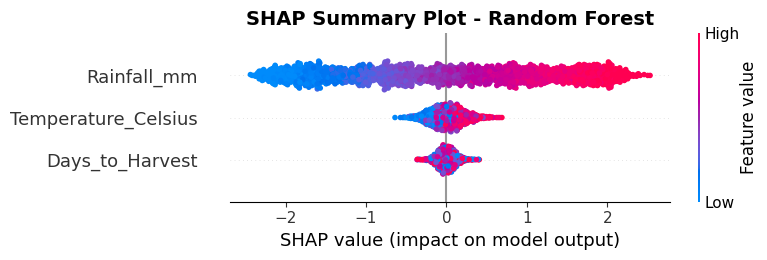

✅ SHAP summary plot saved as 'shap_summary_plot.png'


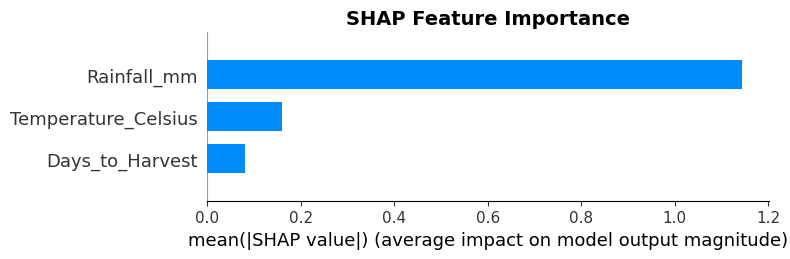

✅ SHAP bar plot saved as 'shap_bar_plot.png'

📊 SHAP Feature Importance Rankings:
            Feature  Mean |SHAP|
        Rainfall_mm     1.144644
Temperature_Celsius     0.158577
    Days_to_Harvest     0.080613
✅ SHAP importance saved as 'shap_importance.csv'

🌲 Feature Importance
            Feature  Importance
        Rainfall_mm    0.736063
Temperature_Celsius    0.157600
    Days_to_Harvest    0.106337


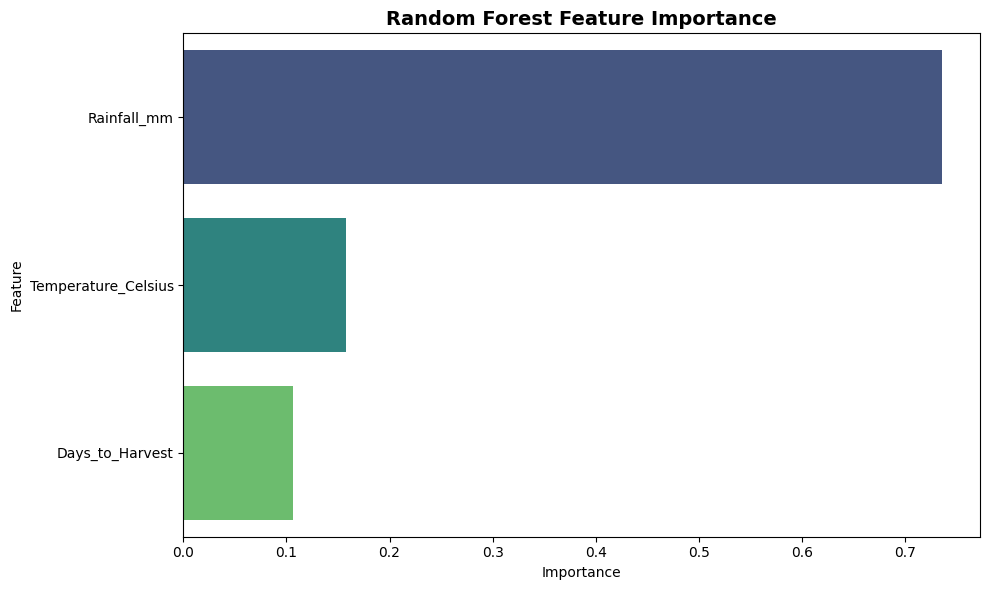

✅ Feature importance saved as 'feature_importance.png'

📈 Predicted vs Actual


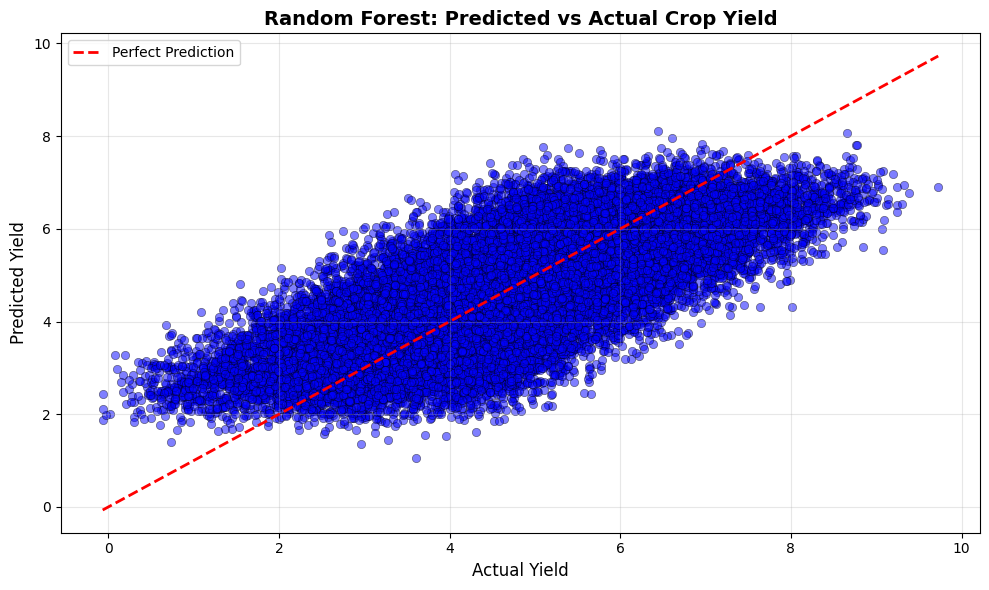

✅ Plot saved as 'predicted_vs_actual.png'

📊 FINAL RESULTS SUMMARY
            Model      MAE     RMSE       R²
Linear Regression 0.882851 1.083756 0.592752
    Random Forest 0.934482 1.145071 0.545367
          XGBoost 0.887588 1.089090 0.588733

🏆 Best Model: Linear Regression (R² = 0.5928)

📁 Files Saved:
   - shap_summary_plot.png
   - shap_bar_plot.png
   - shap_importance.csv
   - feature_importance.png
   - predicted_vs_actual.png

🎉 ANALYSIS COMPLETE!


In [ ]:
# ==========================================
# Cell 2: Complete Analysis
# Run this AFTER Cell 1 (CSV upload + sampling)
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

print("="*50)
print("🚀 STARTING COMPLETE ANALYSIS...")
print("="*50)

# ==========================================
# 1. Preprocess Data
# ==========================================
print("\n📊 Preprocessing data...")
numeric_df = df.select_dtypes(include=[np.number])
numeric_df = numeric_df.fillna(numeric_df.mean())

# Find target column
target_column = None
for col in numeric_df.columns:
    if 'yield' in col.lower() or 'Yield' in col or 'tons' in col.lower():
        target_column = col
        break

if target_column is None:
    target_column = numeric_df.columns[-1]  # Use last column as target

feature_columns = [col for col in numeric_df.columns if col != target_column]

X = numeric_df[feature_columns]
y = numeric_df[target_column]

print(f"✅ Features: {feature_columns}")
print(f"✅ Target: {target_column}")
print(f"✅ X shape: {X.shape}")
print(f"✅ y shape: {y.shape}")

# ==========================================
# 2. Split Data
# ==========================================
print("\n📊 Splitting data...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Training: {X_train.shape[0]:,} records")
print(f"✅ Testing: {X_test.shape[0]:,} records")

# ==========================================
# 3. Train Models
# ==========================================
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"  {name}: MAE={mae:.4f}, RMSE={rmse:.4f}, R²={r2:.4f}")
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2}

results = {}
print("\n🚀 Training Models...")

print("\n⏳ Linear Regression...")
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
results['Linear Regression'] = evaluate("Linear Regression", y_test, lr.predict(X_test_scaled))

print("\n⏳ Random Forest (5-10 min)...")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
results['Random Forest'] = evaluate("Random Forest", y_test, rf.predict(X_test))

print("\n⏳ XGBoost (3-8 min)...")
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train, verbose=False)
results['XGBoost'] = evaluate("XGBoost", y_test, xgb_model.predict(X_test))

print("\n✅ All models trained!")

# ==========================================
# 4. SHAP Analysis
# ==========================================
print("\n" + "="*50)
print("🔍 SHAP Analysis")
print("="*50)

try:
    sample = min(2000, len(X_test))
    X_test_sample = X_test.iloc[:sample]
    print(f"📊 Using {sample} samples for SHAP...")

    explainer = shap.TreeExplainer(rf)
    shap_values = explainer.shap_values(X_test_sample)

    # SHAP Summary Plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_columns, show=False)
    plt.title('SHAP Summary Plot - Random Forest', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_summary_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ SHAP summary plot saved as 'shap_summary_plot.png'")

    # SHAP Bar Plot
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_test_sample, feature_names=feature_columns, plot_type='bar', show=False)
    plt.title('SHAP Feature Importance', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('shap_bar_plot.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("✅ SHAP bar plot saved as 'shap_bar_plot.png'")

    # SHAP Importance Table
    shap_importance = pd.DataFrame({
        'Feature': feature_columns,
        'Mean |SHAP|': np.abs(shap_values).mean(axis=0)
    }).sort_values('Mean |SHAP|', ascending=False)

    print("\n📊 SHAP Feature Importance Rankings:")
    print(shap_importance.to_string(index=False))
    shap_importance.to_csv('shap_importance.csv', index=False)
    print("✅ SHAP importance saved as 'shap_importance.csv'")

except Exception as e:
    print(f"⚠️ SHAP Error (but models are trained): {e}")

# ==========================================
# 5. Feature Importance
# ==========================================
print("\n" + "="*50)
print("🌲 Feature Importance")
print("="*50)

importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved as 'feature_importance.png'")

# ==========================================
# 6. Predicted vs Actual
# ==========================================
print("\n" + "="*50)
print("📈 Predicted vs Actual")
print("="*50)

y_pred = rf.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue', edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Yield', fontsize=12)
plt.ylabel('Predicted Yield', fontsize=12)
plt.title('Random Forest: Predicted vs Actual Crop Yield', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot saved as 'predicted_vs_actual.png'")

# ==========================================
# 7. Final Summary
# ==========================================
print("\n" + "="*50)
print("📊 FINAL RESULTS SUMMARY")
print("="*50)

summary_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'XGBoost'],
    'MAE': [results['Linear Regression']['MAE'],
            results['Random Forest']['MAE'],
            results['XGBoost']['MAE']],
    'RMSE': [results['Linear Regression']['RMSE'],
             results['Random Forest']['RMSE'],
             results['XGBoost']['RMSE']],
    'R²': [results['Linear Regression']['R2'],
           results['Random Forest']['R2'],
           results['XGBoost']['R2']]
})

print(summary_df.to_string(index=False))

best = summary_df.loc[summary_df['R²'].idxmax(), 'Model']
print(f"\n🏆 Best Model: {best} (R² = {summary_df['R²'].max():.4f})")

print("\n📁 Files Saved:")
print("   - shap_summary_plot.png")
print("   - shap_bar_plot.png")
print("   - shap_importance.csv")
print("   - feature_importance.png")
print("   - predicted_vs_actual.png")

print("\n🎉 ANALYSIS COMPLETE!")